## Summary:

This notebook evaluates the optimization performance for varying settings of the bottleneck size.

## Requirements:

- You need to have generated or saved ham-terms and two-rdm instances 
- You need to have trained or saved models for system sizes ```L_{ham-terms}=[4,6,8,10,12,14]``` and ```L_{two-rdm}=[4,6,8]``` 
- You need to have generated or load optimization resutls for these models.






In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from dftqml.autoencoders.optimizer import LatentEnergyOptimizer
from dftqml.autoencoders.ae import load_model
from dftqml.autoencoders import autoencoder_utils 
import torch
import torch.nn.functional as F

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
    }
)

# Optimization Results

In [3]:
loss_dict = {}
percentage_kept_dict = {}
input_type = "ham_terms"

for L in [4, 6, 8, 10, 12, 14]:
    loss_dict[L] = []
    percentage_kept_dict[L] = []
    for z in [L - 3, L - 2, L - 1, L, L + 1, L + 2]:

        checkpoint_kwargs = dict(
                models_dir="../models/bs256",
                input_type=input_type,
                L=L,
                N=L,
                U=4.0,
                interpolation="geometric",
                enable_batchnorm=False,
                hidden_depth=4,
                latent_dim=z,
                min_dim=L**2,
                scaling_factor=20.0 if input_type == "ham_terms" else 1.0,
                weight_decay=None,
                lambda_latent_norm=1e-7,
                lambda_latent_repulsion=1e-7,
                lambda_lipschitz_encoder=1e-9,
                lambda_lipschitz_decoder=1e-8,
                iteration=0,
                linear_encoder=False,
                augment_by_symmetry=True
                )

        checkpoint_dir = autoencoder_utils.checkpoint_dir_path(**checkpoint_kwargs)

        data_path = checkpoint_dir + "/model_opt_lbfgs.hdf5"
        with h5py.File(data_path, "r") as f:
            energy_opt = np.array(f["energy_opt"])
            ref_energy = np.array(f["ref_energy"])
            z_opt = np.array(f["z_opt"])

            inx = np.where(np.linalg.norm(z_opt, axis=1) < 3)[0]

            loss_dict[L].append(
                np.sqrt(np.mean((energy_opt[inx] - ref_energy[inx]) ** 2))
            )
            percentage_kept_dict[L].append(len(inx) / 10000)

<KeysViewHDF5 ['energy_opt', 'loss_history', 'opt_steps', 'potentials', 'ref_energy', 'z_opt']>
<KeysViewHDF5 ['energy_opt', 'loss_history', 'opt_steps', 'potentials', 'ref_energy', 'z_opt']>
<KeysViewHDF5 ['energy_opt', 'loss_history', 'opt_steps', 'potentials', 'ref_energy', 'z_opt']>
<KeysViewHDF5 ['energy_opt', 'loss_history', 'opt_steps', 'potentials', 'ref_energy', 'z_opt']>
<KeysViewHDF5 ['energy_opt', 'loss_history', 'opt_steps', 'potentials', 'ref_energy', 'z_opt']>
<KeysViewHDF5 ['energy_opt', 'loss_history', 'opt_steps', 'potentials', 'ref_energy', 'z_opt']>
<KeysViewHDF5 ['energy_opt', 'loss_history', 'opt_steps', 'potentials', 'ref_energy', 'z_opt']>
<KeysViewHDF5 ['energy_opt', 'loss_history', 'opt_steps', 'potentials', 'ref_energy', 'z_opt']>
<KeysViewHDF5 ['energy_opt', 'loss_history', 'opt_steps', 'potentials', 'ref_energy', 'z_opt']>
<KeysViewHDF5 ['energy_opt', 'loss_history', 'opt_steps', 'potentials', 'ref_energy', 'z_opt']>
<KeysViewHDF5 ['energy_opt', 'loss_histo

/home/felix/vscode/DFTQML-private/.venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/felix/vscode/DFTQML-private/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


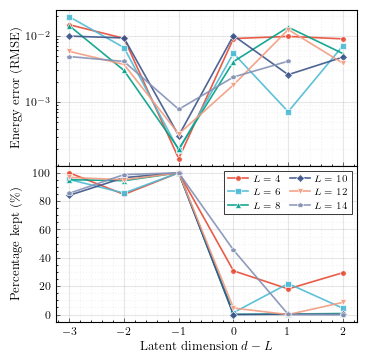

In [4]:
def plot_optimization_loss(loss_dict, percentage_kept_dict):
    """
    Create a plot of latent dimension vs reconstruction loss.

    Parameters
    ----------
    loss_dict : dict
        Dictionary with keys as system sizes L and values as lists of losses
        for different latent dimensions [L-3, L-2, L-1, L, L+1, L+2]

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object
    """
    # Nature single column width (~3.5 inches)
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(3.5, 3.5), gridspec_kw={"hspace": 0.0}
    )

    # Nature-style color palette (colorblind-friendly)
    colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]

    # Marker styles for visual distinction
    markers = ["o", "s", "^", "D", "v", "p"]

    L_values = sorted(loss_dict.keys())

    for idx, L in enumerate(L_values):
        losses = loss_dict[L]
        z_minus_L = [-3, -2, -1, 0, 1, 2]

        ax1.plot(
            z_minus_L,
            losses,
            marker=markers[idx],
            markersize=4,
            linewidth=1.2,
            color=colors[idx],
            label=f"$L={L}$",
            markerfacecolor=colors[idx],
            markeredgewidth=0.5,
            markeredgecolor="white",
            alpha=0.9,
        )
        percentages = percentage_kept_dict[L]
        ax2.plot(
            z_minus_L,
            np.array(percentages) * 100,
            marker=markers[idx],
            markersize=4,
            linewidth=1.2,
            color=colors[idx],
            label=f"$L={L}$",
            markerfacecolor=colors[idx],
            markeredgewidth=0.5,
            markeredgecolor="white",
            alpha=0.9,
        )

    # Set log scale for y-axis
    for ax in (ax1, ax2):

        # Add grid
        ax.grid(True, which="major", linestyle="-", alpha=0.3)
        ax.grid(True, which="minor", linestyle=":", alpha=0.15)
        # Set integer x-axis ticks
        ax.set_xticks([-3, -2, -1, 0, 1, 2])

        # Tick parameters
        ax.tick_params(direction="in", which="both", labelsize=8)
        ax.tick_params(which="major", length=3)
        ax.tick_params(which="minor", length=1.5)

        # Add minor ticks
        ax.minorticks_on()

        # Spine customization
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

    ax1.set_yscale("log")
    # Labels
    ax2.set_xlabel(r"Latent dimension $d - L$", fontsize=9)
    ax1.set_ylabel(r"Energy error (RMSE)", fontsize=9)
    ax2.set_ylabel(r"Percentage kept ($\%$)", fontsize=9)

    # Legend with Nature style
    legend = ax.legend(
        frameon=True,
        loc="best",
        fontsize=7,
        ncol=2,
        columnspacing=1.0,
        handletextpad=0.5,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
    )
    legend.get_frame().set_linewidth(0.6)

    ax1.yaxis.set_label_coords(-0.11, 0.5)  # tweak until aligned
    ax2.yaxis.set_label_coords(-0.11, 0.5)

    fig.tight_layout(pad=0.3)

    return fig


fig = plot_optimization_loss(loss_dict, percentage_kept_dict)
# fig.savefig("optimization_panels.pdf", dpi=300, bbox_inches="tight")

In [5]:
iter_dict = {}
input_type = "two_rdms"
for i in range(3):
    loss_dict = {}

    for L in [4, 6, 8]:
        loss_dict[L] = []
        for z in [L - 3, L - 2, L - 1, L, L + 1, L + 2]:

            checkpoint_kwargs = dict(
                models_dir="../models/bs256",
                input_type=input_type,
                L=L,
                N=L,
                U=4.0,
                interpolation="geometric",
                enable_batchnorm=False,
                hidden_depth=4,
                latent_dim=z,
                min_dim=L**2,
                scaling_factor=20.0 if input_type == "ham_terms" else 1.0,
                weight_decay=None,
                lambda_latent_norm=1e-7,
                lambda_latent_repulsion=1e-7,
                lambda_lipschitz_encoder=1e-9,
                lambda_lipschitz_decoder=1e-8,
                iteration=i,
                linear_encoder=False,
                augment_by_symmetry=False
                )

            checkpoint_dir = autoencoder_utils.checkpoint_dir_path(**checkpoint_kwargs)

            model = load_model(checkpoint_dir, device="cpu")

            n_test_data = 10000

            data_path = f"../data/L{L}-N{L}-U4.0.hdf5"
            with h5py.File(data_path, "r") as f:
                x = f["two_rdms"][-n_test_data + 1 :]

            input_vector = torch.Tensor(x.reshape((9999, L**4)))
            recon_vector = model(input_vector)
            input_vector = torch.Tensor(x)

            loss_dict[L].append(
                np.sqrt(
                    F.mse_loss(input_vector, recon_vector, reduction="mean")
                    .detach()
                    .numpy()
                )
            )
    iter_dict[i] = loss_dict

loss_dict = {}
percentage_kept_dict = {}
nrdmdata = 800

for L in [4, 6, 8]:
    loss_dict[L] = []
    percentage_kept_dict[L] = []
    for z in [L - 3, L - 2, L - 1, L, L + 1, L + 2]:

        checkpoint_kwargs = dict(
                models_dir="../models/bs256",
                input_type=input_type,
                L=L,
                N=L,
                U=4.0,
                interpolation="geometric",
                enable_batchnorm=False,
                hidden_depth=4,
                latent_dim=z,
                min_dim=L**2,
                scaling_factor=20.0 if input_type == "ham_terms" else 1.0,
                weight_decay=None,
                lambda_latent_norm=1e-7,
                lambda_latent_repulsion=1e-7,
                lambda_lipschitz_encoder=1e-9,
                lambda_lipschitz_decoder=1e-8,
                iteration=0,
                linear_encoder=False,
                augment_by_symmetry=False
                )

        checkpoint_dir = autoencoder_utils.checkpoint_dir_path(**checkpoint_kwargs)

        data_path = checkpoint_dir + "/model_opt_lbfgs.hdf5"
        with h5py.File(data_path, "r") as f:
            energy_opt = np.array(f["energy_opt"])[:nrdmdata]
            ref_energy = np.array(f["ref_energy"])[:nrdmdata]
            z_opt = np.array(f["z_opt"])[:nrdmdata]

            inx = np.where((np.linalg.norm(z_opt, axis=1) < 3))[0]

            loss_dict[L].append(
                np.sqrt(np.mean((energy_opt[inx] - ref_energy[inx]) ** 2))
            )
            percentage_kept_dict[L].append(len(inx) / nrdmdata)

(tensor(5.1676, grad_fn=<SumBackward0>), tensor(3.2671, grad_fn=<SumBackward0>))
(tensor(5.1499, grad_fn=<SumBackward0>), tensor(3.4379, grad_fn=<SumBackward0>))
(tensor(5.1465, grad_fn=<SumBackward0>), tensor(3.5155, grad_fn=<SumBackward0>))
(tensor(5.1227, grad_fn=<SumBackward0>), tensor(3.6223, grad_fn=<SumBackward0>))
(tensor(5.1290, grad_fn=<SumBackward0>), tensor(3.7054, grad_fn=<SumBackward0>))
(tensor(5.1651, grad_fn=<SumBackward0>), tensor(3.6750, grad_fn=<SumBackward0>))
(tensor(6.4540, grad_fn=<SumBackward0>), tensor(4.2472, grad_fn=<SumBackward0>))
(tensor(6.5151, grad_fn=<SumBackward0>), tensor(4.2634, grad_fn=<SumBackward0>))
(tensor(6.4809, grad_fn=<SumBackward0>), tensor(4.3375, grad_fn=<SumBackward0>))
(tensor(6.5074, grad_fn=<SumBackward0>), tensor(4.4128, grad_fn=<SumBackward0>))
(tensor(6.4820, grad_fn=<SumBackward0>), tensor(4.4283, grad_fn=<SumBackward0>))
(tensor(6.5022, grad_fn=<SumBackward0>), tensor(4.4939, grad_fn=<SumBackward0>))
(tensor(7.4723, grad_fn=<Sum

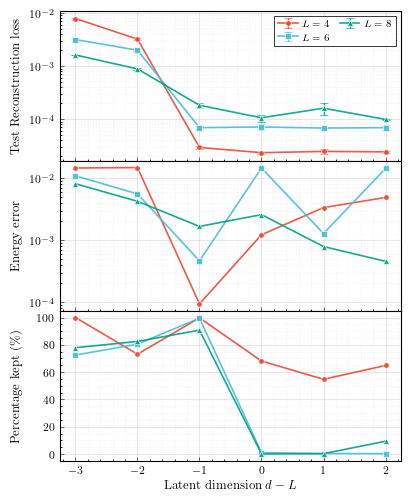

In [6]:
def plot_2rdm_loss(loss_dict, opt_dict, percentage_kept_dict):
    """
    Create a Nature-style plot of latent dimension vs reconstruction loss.

    Parameters
    ----------
    loss_dict : dict
        Dictionary with keys as system sizes L and values as lists of losses
        for different latent dimensions [L-3, L-2, L-1, L, L+1, L+2]

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object
    """
    # Nature single column width (~3.5 inches)
    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, figsize=(3.5, 4.5), gridspec_kw={"hspace": 0.0}
    )

    # Nature-style color palette (colorblind-friendly)
    colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]

    # Marker styles for visual distinction
    markers = ["o", "s", "^", "D", "v", "p"]

    L_values = [4, 6, 8]

    for idx, L in enumerate(L_values):
        losses = np.array([loss_dict[i][L] for i in range(3)])

        mean_losses = losses.mean(axis=0)  # shape: (6,)
        std_losses = losses.std(axis=0)

        z_minus_L = [-3, -2, -1, 0, 1, 2]

        ax1.errorbar(
            z_minus_L,
            mean_losses,
            yerr=std_losses,
            marker=markers[idx],
            markersize=4,
            linewidth=1.2,
            color=colors[idx],
            label=f"$L={L}$",
            markerfacecolor=colors[idx],
            markeredgewidth=0.5,
            markeredgecolor="white",
            capsize=3,
            capthick=1,
            elinewidth=1,
            alpha=0.9,
        )

    # L_values = sorted(opt_dict.keys())

    for idx, L in enumerate(L_values):
        losses = opt_dict[L]
        z_minus_L = [-3, -2, -1, 0, 1, 2]

        ax2.plot(
            z_minus_L,
            losses,
            marker=markers[idx],
            markersize=4,
            linewidth=1.2,
            color=colors[idx],
            label=f"$L={L}$",
            markerfacecolor=colors[idx],
            markeredgewidth=0.5,
            markeredgecolor="white",
            alpha=0.9,
        )

        percentages = percentage_kept_dict[L]
        ax3.plot(
            z_minus_L,
            np.array(percentages) * 100,
            marker=markers[idx],
            markersize=4,
            linewidth=1.2,
            color=colors[idx],
            label=f"$L={L}$",
            markerfacecolor=colors[idx],
            markeredgewidth=0.5,
            markeredgecolor="white",
            alpha=0.9,
        )

    # Set log scale for y-axis
    for ax in (ax1, ax2, ax3):

        # Add grid
        ax.grid(True, which="major", linestyle="-", alpha=0.3)
        ax.grid(True, which="minor", linestyle=":", alpha=0.15)
        # Set integer x-axis ticks
        ax.set_xticks([-3, -2, -1, 0, 1, 2])

        # Tick parameters
        ax.tick_params(direction="in", which="both", labelsize=8)
        ax.tick_params(which="major", length=3)
        ax.tick_params(which="minor", length=1.5)

        # Add minor ticks
        ax.minorticks_on()

        # Spine customization
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

    ax1.set_yscale("log")
    ax2.set_yscale("log")

    # Labels
    ax3.set_xlabel(r"Latent dimension $d - L$", fontsize=9)
    ax2.set_ylabel(r"Energy error", fontsize=9)
    ax1.set_ylabel(r"Test Reconstruction loss", fontsize=9)
    ax3.set_ylabel(r"Percentage kept ($\%$)", fontsize=9)

    # Legend with Nature style
    legend = ax1.legend(
        frameon=True,
        loc="best",
        fontsize=7,
        ncol=2,
        columnspacing=1.0,
        handletextpad=0.5,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
    )
    legend.get_frame().set_linewidth(0.6)

    ax1.yaxis.set_label_coords(-0.11, 0.5)  # tweak until aligned
    ax2.yaxis.set_label_coords(-0.11, 0.5)
    ax3.yaxis.set_label_coords(-0.11, 0.5)

    fig.tight_layout(pad=-1.5)

    return fig


fig = plot_2rdm_loss(iter_dict, loss_dict, percentage_kept_dict)
# fig.savefig("2rm_panels.pdf", dpi=300, bbox_inches="tight")

# Study error distribution

In [ ]:
import os

counter = 0
total = 0
opt_name = "model_opt_lbfgs.hdf5"
model_family = "bs256/ae"
linear_encoder = False
augment_by_symmetry = False
for dirpath, dirnames, filenames in os.walk(f"../models/{model_family}"):
    if opt_name in filenames:
        counter += 1
    if "training_info.json" in filenames:
        total +=1
print(counter, "optimization files found out of", total, "models")

54 optimization files found out of 359 models


In [ ]:
def load_opt_data(L, N, input_type = "ham_terms", latent_diff = -1, linear_encoder=linear_encoder, opt_name=opt_name,
                  augment_by_symmetry=augment_by_symmetry, return_loss_history=False, return_opt_steps=False, n_data=None, iteration=0):
    checkpoint_kwargs = dict(
        models_dir="../models/bs256",
        input_type=input_type,
        L=L,
        N=N,
        U=4.0,
        interpolation="geometric",
        enable_batchnorm=False,
        hidden_depth=4,
        latent_dim=L + latent_diff,
        min_dim=L**2,
        scaling_factor=20.0 if input_type == "ham_terms" else 1.0,
        weight_decay=None,
        lambda_latent_norm=1e-7,
        lambda_latent_repulsion=1e-7,
        lambda_lipschitz_encoder=0. if linear_encoder else 1e-9,
        lambda_lipschitz_decoder=1e-8,
        iteration=iteration,
        linear_encoder=linear_encoder,
        augment_by_symmetry=augment_by_symmetry
    )

    checkpoint_dir = autoencoder_utils.checkpoint_dir_path(**checkpoint_kwargs)
    # checkpoint_dir

    with h5py.File(checkpoint_dir+f"/{opt_name}", 'r') as f:
        # start_idx = f.attrs["start_idx"]
        # end_idx = f.attrs["end_idx"]
        # n_data = end_idx - start_idx
        if n_data is None:
            n_data = f["/ref_energy"].shape[0]
        ref_energies = f["/ref_energy"][:n_data]
        opt_energies = f["/energy_opt"][:n_data]
        opt_z = f["/z_opt"][:n_data]
        loss_history = f["/loss_history"][:n_data]
        opt_steps = f["/opt_steps"][:n_data]
    if return_loss_history and return_opt_steps:
        return ref_energies, opt_energies, opt_z, loss_history, opt_steps
    elif return_loss_history:
        return ref_energies, opt_energies, opt_z, loss_history
    elif return_opt_steps:
        return ref_energies, opt_energies, opt_z, opt_steps
    else:
        return ref_energies, opt_energies, opt_z


def performance_plot(L, N, input_type = "ham_terms", latent_diff = -1, n_data=None, iteration=0):
    ref_energies, opt_energies, opt_z = load_opt_data(L, N, input_type, latent_diff, n_data=n_data, iteration=iteration)
    norm_opt_z = np.linalg.norm(opt_z, axis=1)

    plt.figure(figsize=(6, 6))
    sc = plt.scatter(ref_energies, opt_energies, c=norm_opt_z, cmap='viridis', s=1)
    plt.plot([ref_energies.min(), ref_energies.max()],
             [ref_energies.min(), ref_energies.max()],
             'k--', label='x = y', alpha = 0.5)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel('Reference Energy')
    plt.ylabel('Optimized Energy')
    plt.legend()
    plt.colorbar(sc, label='Norm of opt_z')
    plt.title(f"L = {L}, N = {N}, '{input_type}', latent_dim = {L+latent_diff}\n"
              f"{len(ref_energies)} data points")
    plt.show()

def error_scatterplot(L, N, input_type = "ham_terms", latent_diff = -1, logscale=False, iteration=0):
    ref_energies, opt_energies, opt_z = load_opt_data(L, N, input_type, latent_diff, iteration=iteration)
    errors = np.abs(opt_energies - ref_energies)
    norm_opt_z = np.linalg.norm(opt_z, axis=1)

    plt.figure(figsize=(6, 6))
    sc = plt.scatter(norm_opt_z, errors, c=ref_energies, cmap='viridis', s=4)
    plt.axhline(0, color='k', linestyle='--', alpha=0.5)
    plt.xlabel('Norm of opt_z')
    plt.ylabel('Optimization Error (Opt - Ref)')
    plt.colorbar(sc, label='Reference Energy')
    plt.title(f"L = {L}, N = {N}, '{input_type}', latent_dim = {L+latent_diff}\n"
              f"{len(ref_energies)} data points")
    plt.axvline(2, color='red', linestyle='--', alpha=0.7, label='Norm = 2')
    plt.yscale('log') if logscale else None
    plt.show()

def log_error_hist(L, N, input_type = "ham_terms", latent_diff = -1, epsilon=1e-8, negative=False, iteration=0, **hist_kwargs):
    ref_energies, opt_energies, opt_z = load_opt_data(L, N, input_type, latent_diff, iteration=iteration)
    errors = opt_energies - ref_energies
    bins = np.linspace(np.log10(1e-7), np.log10(1e-1), 101)
    if negative:
        plt.hist(np.log10(-errors[np.where(errors <= 0)] + epsilon), bins=bins, **hist_kwargs)
    else:
        plt.hist(np.log10(errors[np.where(errors > 0)] + epsilon), bins=bins, **hist_kwargs)
    return errors

def error_hist(L, N, input_type = "ham_terms", latent_diff = -1, iteration=0, **hist_kwargs):
    ref_energies, opt_energies, opt_z = load_opt_data(L, N, input_type, latent_diff, iteration=iteration)
    errors = opt_energies - ref_energies
    bins = np.linspace(-2e-3, 2e-3, 101)
    plt.hist(errors, bins=bins, **hist_kwargs)
    return errors


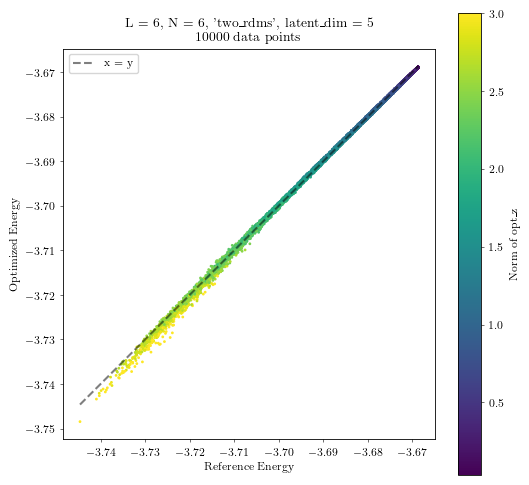

In [ ]:
L, N = 6, 6
input_type = "two_rdms"
latent_diff = -1

performance_plot(L, N, input_type, latent_diff, n_data=None, iteration=0)

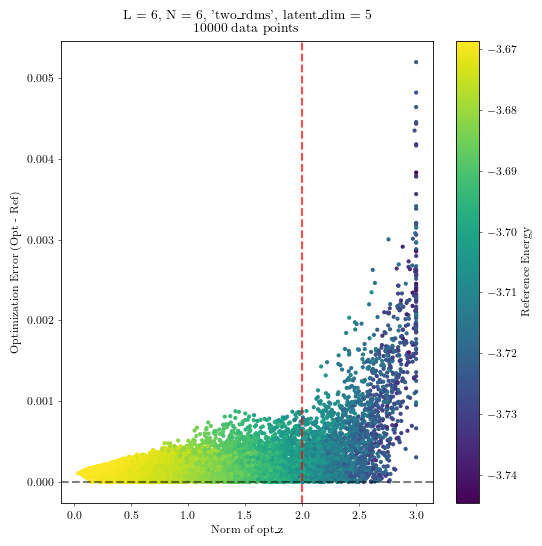

In [ ]:
error_scatterplot(L, N, input_type, -1, logscale=False)

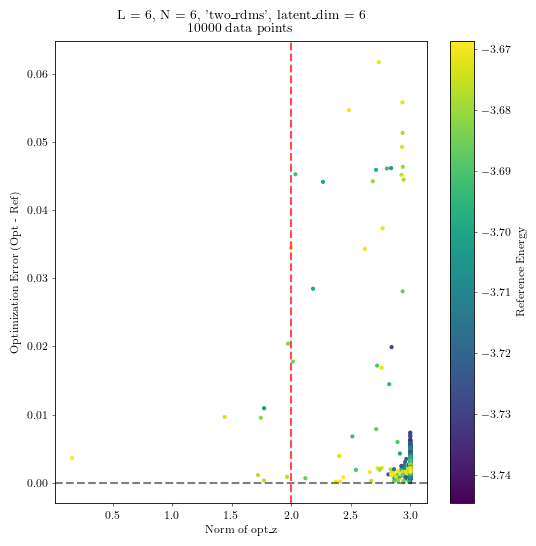

In [ ]:
error_scatterplot(L, N, input_type, 0)

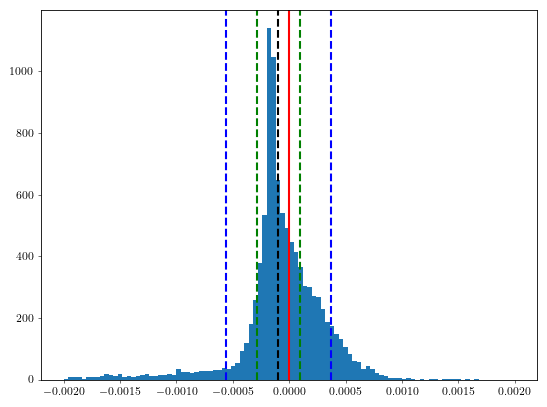

In [ ]:
errors = error_hist(L, N, input_type, latent_diff)
plt.axvline(0, c='r')

err_mean = np.mean(errors)
plt.axvline(err_mean, c='k', linestyle='--')

err_std = np.std(errors)
plt.axvline(err_mean+err_std, c='b', linestyle='--')
plt.axvline(err_mean-err_std, c='b', linestyle='--')

std_without_fat_tails = np.std(errors[np.abs(errors - err_mean) < err_std])
plt.axvline(err_mean+std_without_fat_tails, c='g', linestyle='--')
plt.axvline(err_mean-std_without_fat_tails, c='g', linestyle='--')

#plt.yscale('log')

Plot median norm

In [ ]:
# # Assuming latent_diffs is defined as [-3, -2, -1, 0, 1, 2]
# # and LN_list is [(4, 4), (6, 6), (8, 8), (10, 10), (12, 12), (14, 14)]
# LN_list = [(4, 4), (6, 6), (8, 8), (10, 10), (12, 12), (14, 14)]
# latent_diffs = [-3, -2, -1, 0, 1, 2]

# colors = plt.cm.plasma(np.linspace(0, 1, len(LN_list)))

# plt.figure(figsize=(8, 6))

# for (L, N), color in zip(LN_list, colors):
#     med_norms = []
#     for latent_diff in latent_diffs[:-1]:
#         try:
#             ref_energies, opt_energies, opt_z = load_opt_data(L, N, "ham_terms", latent_diff)
#             med_norm = np.median(np.linalg.norm(opt_z, axis=1))
#             med_norms.append(med_norm)
#         except FileNotFoundError:
#             med_norms.append(np.nan)  # or skip
#     plt.plot(latent_diffs[:-1], med_norms, marker='o', color=color, label=f"L={L}, N={N}")

# plt.xlabel("Latent dimension difference (latent_diff)")
# plt.ylabel("Median norm of latent variable z")
# plt.title("Median norm of z vs latent_diff for different system sizes")
# plt.legend()
# plt.grid(True)
# plt.show()

Comparison

In [ ]:
# LN_list = [(4, 4), (6, 6), (8, 8), (10, 10), (12, 12), (14, 14)]
# input_types = ["ham_terms"]
# latent_diff = -1

# colors = plt.cm.plasma(np.linspace(0, 1, len(LN_list)))

# fig, ax = plt.subplots(1, 1, sharex=True, figsize=(6, 8), gridspec_kw={"hspace": 0})

# # for ax, input_type in zip(axes, input_types):
# for (L, N), color in zip(LN_list, colors):
#     plt.sca(ax)
#     log_error_hist(L, N, input_type, latent_diff, alpha=0.5, color=color, label=f"L={L}, N={N}", density=True, negative=True)
# ax.legend(title=f"{input_type}")
# ax.set_ylabel("Probability density")

# plt.xlabel("log10(|opt_energy - true_energy|)")
# plt.ylabel("Probability density")
# ax.set_title("Variational optimization energy errors (latent_dim = L-1)")
# plt.show()

In [ ]:
# L, N = 8, 8
# colors = plt.cm.plasma(np.linspace(0, 1, 6))
# latent_diffs = []

# for latent_diff, color in zip(np.arange(-3, 3), colors):
#     try:
#        log_error_hist(L, N, latent_diff=latent_diff, alpha=0.5, color=color, label=f"{L + latent_diff} (L{latent_diff:+})", negative=True)
#        latent_diffs.append(latent_diff)
#     except FileNotFoundError:
#         pass

# plt.legend(title="latent_dim")
# plt.xlabel("log10(|opt_energy - true_energy|)")
# plt.ylabel("Count")
# plt.title(f"Error histograms for different latent_dim (L={L}, N={N})")
# plt.show()

In [ ]:
# L, N = 6, 6
# colors = plt.cm.plasma(np.linspace(0, 1, 6))
# latent_diffs = []

# for latent_diff, color in zip(np.arange(-3, 3), colors):
#     try:
#        log_error_hist(L, N, latent_diff=latent_diff, alpha=0.5, color=color, label=f"{L + latent_diff} (L{latent_diff:+})")
#        latent_diffs.append(latent_diff)
#     except FileNotFoundError:
#         pass

# plt.legend(title="latent_dim")
# plt.xlabel("log10(|opt_energy - true_energy|)")
# plt.ylabel("Count")
# plt.title(f"Error histograms for different latent_dim (L={L}, N={N})")
# plt.show()

check worst

In [ ]:
# def get_checkpoint_dir(L, N, input_type = "ham_terms", latent_diff = -1, linear_encoder=True):
#     checkpoint_kwargs = dict(
#         models_dir="models",
#         input_type=input_type,
#         L=L,
#         N=N,
#         U=4.0,
#         interpolation="geometric",
#         enable_batchnorm=False,
#         hidden_depth=4,
#         latent_dim=L + latent_diff,
#         min_dim=L**2,
#         scaling_factor=20.0 if input_type == "ham_terms" else 1.0,
#         weight_decay=None,
#         lambda_latent_norm=1e-7,
#         lambda_latent_repulsion=1e-7,
#         lambda_lipschitz_encoder=0. if linear_encoder else 1e-8,
#         lambda_lipschitz_decoder=1e-8,
#         iteration=0,
#         linear_encoder=linear_encoder
#     )

#     return autoencoder_utils.checkpoint_dir_path(**checkpoint_kwargs)

In [ ]:
# check = (14, 14, "ham_terms", -1)
# checkpoint_dir = get_checkpoint_dir(*check)

# input_file = f"../data/L{check[0]}-N{check[1]}-U{4.0}_reduced.hdf5"

# with h5py.File(input_file, "r") as f:
#     print("Datasets found in the file:")
#     for name, dataset in f.items():
#         print(f"  - {name}: shape={dataset.shape}, dtype={dataset.dtype}")
#     print("\nSummary:")
#     for name, dataset in f.items():
#         if dataset.shape and dataset.shape[0] > 0:
#             print(f"  {name}: {dataset.shape[0]} datapoints")
#     # state_vector_arr = f["ground_states"][-10000:]
#     ground_energies_arr = f["ground_energies"][-10000:]
#     potentials_arr = f["potentials"][-10000:]
#     # densities_arr = f["densities"][-10000:]
#     # two_rdms_arr = f["two_rdms"][-10000:]
#     # states_arr = f["ground_states"][-10000:]

In [ ]:
# check = (4, 4, "ham_terms", -1)
# # check worst point of optimization
# ref_energies, opt_energies, opt_z, opt_loss_history = load_opt_data(*check, return_loss_history=True)
# errors = opt_energies - ref_energies
# sorted_indices = np.argsort(errors)[::-1]
# worst_idx = sorted_indices[0]


In [ ]:
# # Fancy print highest 10 errors, and lowest 10 errors
# print("Top 10 highest errors:")
# for i in range(10):
#     idx = sorted_indices[i]
#     print(f"Rank {i+1}: Index {idx}, Error: {errors[idx]:.6e}")
# print("\nTop 10 lowest errors:")
# for i in range(1, 11):
#     idx = sorted_indices[-i]
#     print(f"Rank {i}: Index {idx}, Error: {errors[idx]:.6e}")

In [ ]:
# worst_idx = sorted_indices[0]

# print(f"Worst optimization error at index {worst_idx}:")
# print(f"  Reference energy: {ref_energies[worst_idx]}")
# print(f"  Optimized energy: {opt_energies[worst_idx]}")
# print(f"  Error: {errors[worst_idx]}")

In [ ]:
# np.std(potentials_arr[worst_idx]), ground_energies_arr[worst_idx]

In [ ]:

# latentopt = LatentEnergyOptimizer(checkpoint_dir, system_params={"n_sites": check[0], "n_particles": check[1], "u": 4.0})

In [8]:

# # Hyperparameters for optimization
# init_z=None
# opt=torch.optim.LBFGS
# lr=0.1
# max_iter=100
# energy_tol=1e-8
# grad_tol=3e-4
# well_size=3.
# # well_penalty_strength=50.0
# verbose=True
# use_grad_tol=True
# print_interval=1
# return_loss_history=True
# return_grad_history=True

In [ ]:
# z_opt, energy_opt, loss_history, grad_history = latentopt.minimize(potentials_arr[worst_idx], init_z=init_z, opt=opt, lr=lr, max_iter=max_iter, energy_tol=energy_tol, well_size=well_size, well_penalty_strength=well_penalty_strength, verbose=verbose, print_interval=print_interval, return_loss_history=return_loss_history, return_grad_history=True, grad_tol=grad_tol, use_grad_tol=use_grad_tol)

In [ ]:
# print(f"Optimized energy: {energy_opt}")
# print(f"Ground energy: {ground_energies_arr[worst_idx]}")
# print(f"Opt energy: {opt_energies[worst_idx]}")
# print(f"Error after optimization: {energy_opt - ground_energies_arr[worst_idx]}")
# print(f"Error of previous optimization: {opt_energies[worst_idx] - ground_energies_arr[worst_idx]}")


In [ ]:
# def rms_with_outlier_rejection(errors, method="mad", k=3.5, p=99.5, on="logabs", eps=1e-16):
#     """Compute RMS after excluding outliers using robust rules.

#     Parameters
#     ----------
#     errors : array-like
#         Signed errors (opt_energies - ref_energies).
#     method : {"mad", "iqr", "percentile"}
#         Outlier rule to apply.
#         - "mad": robust z-score via Median Absolute Deviation; exclude |z| > k
#         - "iqr": Tukey fences; keep within [Q1 - k*IQR, Q3 + k*IQR] (k≈1.5–3)
#         - "percentile": symmetric clipping; keep between [100-p, p] percentiles
#     k : float
#         Threshold for MAD/IQR methods (default 3.5 ≈ ~3-sigma robust).
#     p : float
#         Upper percentile for symmetric clipping (default 99.5 keeps central 99%).
#     on : {"logabs", "linear"}
#         Space on which to detect outliers. "logabs" applies the rule to
#         log10(|error|+eps) which is typically better for heavy-tailed,
#         strictly-positive magnitudes; "linear" applies to the raw errors.
#     eps : float
#         Small value to avoid log(0).

#     Returns
#     -------
#     rms : float
#         Root-mean-square computed on the filtered errors (np.nan if empty).
#     mask : ndarray of bool
#         Boolean mask over the original errors indicating which points were kept.
#     """
#     e = np.asarray(errors).ravel()
#     # Map to detection space
#     if on == "logabs":
#         x = np.log10(np.abs(e) + eps)
#     else:
#         x = e.copy()
#     # Valid mask (finite)
#     finite = np.isfinite(x)
#     x_valid = x[finite]
#     e_valid = e[finite]
#     if x_valid.size == 0:
#         return np.nan, np.zeros_like(e, dtype=bool)
#     if method == "mad":
#         med = np.median(x_valid)
#         mad = np.median(np.abs(x_valid - med))
#         mad = mad if mad > 0 else eps
#         z = 0.6744897501960817 * (x_valid - med) / mad  # 0.6745 ≈ Phi^{-1}(0.75)
#         keep_valid = np.abs(z) <= k
#     elif method == "iqr":
#         q1, q3 = np.percentile(x_valid, [25, 75])
#         iqr = q3 - q1
#         lo, hi = q1 - k * iqr, q3 + k * iqr
#         keep_valid = (x_valid >= lo) & (x_valid <= hi)
#     elif method == "percentile":
#         lo, hi = np.percentile(x_valid, [100 - p, p])
#         keep_valid = (x_valid >= lo) & (x_valid <= hi)
#     else:
#         # No filtering
#         keep_valid = np.ones_like(x_valid, dtype=bool)
#     kept_errors = e_valid[keep_valid]
#     # Build full mask
#     mask = np.zeros_like(e, dtype=bool)
#     mask[np.where(finite)[0][keep_valid]] = True
#     if kept_errors.size == 0:
#         return np.nan, mask
#     rms = np.sqrt(np.mean(kept_errors ** 2))
#     return rms, mask

In [ ]:
# def cost_fn(z):
#     return latentopt.energy_from_latent(z, potentials_arr[0])

# # Define a grid around z_opt[0] and z_opt[1]
# n_points = 40
# z0_range = np.linspace(z_opt[0,0].item() - 1.0, z_opt[0,0].item() + 1.0, n_points)
# z1_range = np.linspace(z_opt[0,1].item() - 1.0, z_opt[0,1].item() + 1.0, n_points)
# Z0, Z1 = np.meshgrid(z0_range, z1_range)
# E = np.zeros_like(Z0)

# # Evaluate energy at each grid point (fix z2)
# for i in range(n_points):
#     for j in range(n_points):
#         z = 0#torch.tensor([[Z0[i, j], Z1[i, j], *[z_opt[0,i].item() for i in range(z_opt.shape[-1] - 2)]], dtype=torch.float32))
#         with torch.no_grad():
#             E[i, j] = cost_fn(z).item()

# fig = plt.figure(figsize=(8,6))
# ax = fig.add_subplot(111, projection='3d')
# ax.plot_surface(Z0, Z1, E, cmap='viridis', alpha=0.85)
# ax.set_xlabel('Latent variable 1')
# ax.set_ylabel('Latent variable 2')
# ax.set_zlabel('Energy')
# ax.set_title('Energy landscape (z3 fixed)')
# ax.scatter(z_opt[0,0].item(), z_opt[0,1].item(), cost_fn(z_opt).item(), color='r', s=60, label='z_opt')
# ax.legend()
# plt.tight_layout()
# plt.show()